# Week 7 / Stage 3 — Local Directions via Clustering

## What it does
- loads the Week 5 VAE + digit classifier + thickness probe
- extracts latent means and paired thin/thick deltas
- fits one **global** direction and several **local** direction families via k-means
- evaluates global vs local steering across a grid of `alpha`
- saves CSV tables, plots, and `memo_week7.md`


---
Stage 3: Local directions via clustering for latent steering
------------------------------------------------------------
Why:
  Week 6 used a single global steering direction d.
  The project hypothesis says latent space may be piecewise linear,
  so different regions may need different local directions d_k.

What this script does:
  1) load Week 5/6 artifacts (VAE + digit classifier + thickness probe),
  2) extract latent means z on the train set,
  3) cluster z with k-means for several K values,
  4) learn one local direction per cluster from paired thin/thick deltas,
  5) compare global vs local steering on the test set,
  6) save CSVs + plots + a 1-page memo.

How:
  direction per cluster k is estimated as mean(z_thick - z_thin | cluster(z)=k)
  and normalized. At inference time we assign the input z to a cluster and use d_k.

For what:
  This directly implements Stage 3 from the proposal and produces a weekly package:
  memo + results tables + plots + next-step notes.


In [1]:
%pip install -q torch torchvision matplotlib pandas tqdm scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
import os
import json
import time
import math
import random
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

from sklearn.cluster import MiniBatchKMeans

from IPython.display import display, Image


In [ ]:
# Fill these paths manually
cfg: Dict[str, Any] = {
    "seed": 42,
    "device": "cuda",

    "artifacts": {
        "week5_config_json": "../week5/output/kaggle/working/runs/20260224_074746_week5/config.json",
        "vae_checkpoint": "../week5/output/kaggle/working/runs/20260224_074746_week5/checkpoints/vae_epoch020.pt",
        "digit_classifier_checkpoint": "../week5/output/kaggle/working/runs/20260224_074746_week5/checkpoints/clf_best.pt",
        "thickness_probe_checkpoint": "../week5/output/kaggle/working/runs/20260224_074746_week5/checkpoints/probe_best.pt",
    },

    "run": {
        "root": "runs",
        "tag": "week7_local_dirs",
    },

    "data": {
        "mnist_root": "../output/kaggle/working/data/MNIST/raw",
        "batch_size": 128,
        "num_workers": 0,
        "subset": None,
    },

    "probe": {
        "aug": {
            "thin_k": 1,
            "thick_k": 1,
            "blend": 0.2,
        }
    },

    "cluster": {
        "k_values": [2, 4, 8, 16],
        "fit_max_points": 25000,
        "direction_max_batches": 250,
        "min_cluster_points": 32,
        "mbk_batch_size": 2048,
    },

    "steer": {
        "alphas": [-4.0, -2.0, -1.0, -0.5, 0.0, 0.5, 1.0, 2.0, 4.0],
        "preview_alphas": [0.0, 1.0, 2.0],
        "preview_n": 8,
    },

    "selection": {
        "max_acc_drop_vs_recon": 0.02,
    },
}


In [4]:
# ------------------------ helpers ------------------------

def get_device(name: str) -> torch.device:
    if name == "cuda" and torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def seed_worker(worker_id: int):
    worker_seed = (torch.initial_seed() + worker_id) % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def save_json(path: str, obj: dict) -> None:
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)


def make_run_dir(root: str, tag: str) -> str:
    ts = time.strftime("%Y%m%d_%H%M%S")
    run_dir = os.path.join(root, f"{ts}_{tag}")
    os.makedirs(os.path.join(run_dir, "plots"), exist_ok=False)
    os.makedirs(os.path.join(run_dir, "checkpoints"), exist_ok=True)
    return run_dir


def require_existing_file(path: str, name: str) -> str:
    if not isinstance(path, str) or not path.strip() or "TODO/" in path:
        raise ValueError(f"Fill cfg with a real path for: {name}")
    if not os.path.isfile(path):
        raise FileNotFoundError(f"{name} was not found: {path}")
    return path


def prepare_dir_path(path: str, name: str) -> str:
    if not isinstance(path, str) or not path.strip() or "TODO/" in path:
        raise ValueError(f"Fill cfg with a real path for: {name}")
    os.makedirs(path, exist_ok=True)
    return path


# ------------------------ data ------------------------

def get_mnist_loaders(
    data_root: str,
    batch_size: int,
    num_workers: int,
    subset: Optional[int] = None,
):
    # keep torchvision import local, so the module can still be imported in environments
    # where torchvision is not preloaded correctly.
    from torchvision import datasets, transforms

    tfm = transforms.ToTensor()

    train_ds = datasets.MNIST(root=data_root, train=True, download=True, transform=tfm)
    test_ds = datasets.MNIST(root=data_root, train=False, download=True, transform=tfm)

    if subset is not None:
        train_ds = Subset(train_ds, list(range(int(subset))))

    g = torch.Generator()
    g.manual_seed(int(cfg["seed"]))

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        worker_init_fn=seed_worker,
        generator=g,
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        worker_init_fn=seed_worker,
        generator=g,
    )
    return train_loader, test_loader


In [5]:
# ------------------------ models ------------------------

class ConvEncoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.ReLU(inplace=True),
        )
        self.fc_mu = nn.Linear(64 * 7 * 7, latent_dim)
        self.fc_lv = nn.Linear(64 * 7 * 7, latent_dim)

    def forward(self, x):
        h = self.net(x).flatten(1)
        return self.fc_mu(h), self.fc_lv(h)


class ConvDecoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 64 * 7 * 7)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 1, 4, 2, 1),
        )

    def forward(self, z):
        h = self.fc(z).view(z.size(0), 64, 7, 7)
        return self.net(h)


class ConvVAE(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.enc = ConvEncoder(latent_dim)
        self.dec = ConvDecoder(latent_dim)

    def reparam(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, lv = self.enc(x)
        z = self.reparam(mu, lv)
        x_logits = self.dec(z)
        return x_logits, mu, lv


class DigitCNN(nn.Module):
    def __init__(self, feat_dim: int = 128):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, 1, 1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.fc1 = nn.Linear(64 * 7 * 7, feat_dim)
        self.fc2 = nn.Linear(feat_dim, 10)

    def forward(self, x, return_feat: bool = False):
        h = self.conv(x).flatten(1)
        feat = F.relu(self.fc1(h))
        logits = self.fc2(feat)
        return (logits, feat) if return_feat else logits


class ThicknessProbe(nn.Module):
    def __init__(self, in_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 2),
        )

    def forward(self, feat):
        return self.net(feat)



In [6]:
# ------------------------ image/latent utilities ------------------------

def gray_dilate(x: torch.Tensor, iters: int = 1, k: int = 3) -> torch.Tensor:
    out = x
    pad = k // 2
    for _ in range(iters):
        out = F.max_pool2d(out, kernel_size=k, stride=1, padding=pad)
    return out


def gray_erode(x: torch.Tensor, iters: int = 1, k: int = 3) -> torch.Tensor:
    out = x
    pad = k // 2
    for _ in range(iters):
        out = -F.max_pool2d(-out, kernel_size=k, stride=1, padding=pad)
    return out


@torch.no_grad()
def thickness_transform(x: torch.Tensor, mode: str, iters: int, blend: float = 0.2) -> torch.Tensor:
    if mode == "thick":
        out = gray_dilate(x, iters=iters, k=3)
    elif mode == "thin":
        out = gray_erode(x, iters=iters, k=3)
    else:
        raise ValueError("mode must be 'thin' or 'thick'")

    eps = 1e-6
    out = out / (out.amax(dim=(1, 2, 3), keepdim=True) + eps)
    out = (1.0 - blend) * out + blend * x
    return out.clamp(0.0, 1.0)


@torch.no_grad()
def encode_mu(vae: nn.Module, x: torch.Tensor) -> torch.Tensor:
    mu, _ = vae.enc(x)
    return mu


@torch.no_grad()
def decode_sigmoid(vae: nn.Module, z: torch.Tensor) -> torch.Tensor:
    return torch.sigmoid(vae.dec(z))


@torch.no_grad()
def clf_logits_and_feat(clf: nn.Module, x: torch.Tensor):
    return clf(x, return_feat=True)


@torch.no_grad()
def probe_logits_on_imgs(clf: nn.Module, probe: nn.Module, x: torch.Tensor) -> torch.Tensor:
    _, feat = clf_logits_and_feat(clf, x)
    return probe(feat)


@torch.no_grad()
def feature_l2_on_imgs(clf: nn.Module, x_a: torch.Tensor, x_b: torch.Tensor) -> torch.Tensor:
    _, feat_a = clf_logits_and_feat(clf, x_a)
    _, feat_b = clf_logits_and_feat(clf, x_b)
    return (feat_a - feat_b).pow(2).sum(dim=1).sqrt()


@torch.no_grad()
def mean_ink(x: torch.Tensor) -> torch.Tensor:
    return x.mean(dim=(1, 2, 3))



In [ ]:
from scipy.stats import spearmanr

# ------------------------ stage 3 core ------------------------
def normalize_direction(
        d: np.ndarray, 
        eps: float = 1e-8
    ) -> np.ndarray:
    # Normalize direction to unit length for fair alpha comparison
    n = float(np.linalg.norm(d))
    if n < eps:
        return d.astype(np.float32)
    return (d / n).astype(np.float32)

@torch.no_grad()
def extract_train_latents_and_deltas(
        vae: nn.Module,
        loader: DataLoader,
        thin_k: int,
        thick_k: int,
        blend: float,
        max_batches: Optional[int],
        device: torch.device,
    ) -> Dict[str, np.ndarray]:
    # Z: base latents, D: thick-thin latent deltas, Y: digit labels
    zs, deltas, ys = [], [], []
    ink_gap_sum = 0.0
    ink_n = 0

    for bi, (x, y) in enumerate(loader):
        # Optional speed-up: use only first max_batches batches
        if max_batches is not None and bi >= max_batches:
            break

        x = x.to(device)
        y = y.to(device)

        # Create paired thin/thick versions of the same image
        x_thin = thickness_transform(x, mode="thin", iters=thin_k, blend=blend)
        x_thick = thickness_transform(x, mode="thick", iters=thick_k, blend=blend)

        # Encode original / thin / thick images into latent means
        z = encode_mu(vae, x)
        z_thin = encode_mu(vae, x_thin)
        z_thick = encode_mu(vae, x_thick)

        # Store base latent and local thickness direction delta
        zs.append(z.detach().cpu().numpy())
        deltas.append((z_thick - z_thin).detach().cpu().numpy())
        ys.append(y.detach().cpu().numpy())

        # Diagnostic: thick images should contain more ink than thin ones
        ink_gap_sum += (mean_ink(x_thick) - mean_ink(x_thin)).sum().item()
        ink_n += x.size(0)

    # Concatenate all batches into full train arrays
    Z = np.concatenate(zs, axis=0)
    D = np.concatenate(deltas, axis=0)
    Y = np.concatenate(ys, axis=0)

    return {
        "Z": Z.astype(np.float32),
        "D": D.astype(np.float32),
        "Y": Y.astype(np.int64),
        "ink_gap_mean": float(ink_gap_sum / max(1, ink_n)),
    }

def maybe_subsample(
        X: np.ndarray, 
        max_points: Optional[int], 
        seed: int
    ) -> np.ndarray:
    # Use all points unless subsampling is requested
    if max_points is None or len(X) <= int(max_points):
        return np.arange(len(X))
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), size=int(max_points), replace=False)
    return np.sort(idx)

def fit_global_and_local_direction_families(
        Z: np.ndarray,
        D: np.ndarray,
        k_values: List[int],
        fit_max_points: Optional[int],
        min_cluster_points: int,
        seed: int,
        mbk_batch_size: int,
    ) -> Tuple[Dict[str, Any], pd.DataFrame]:
    # Global direction = normalized mean delta over all train samples
    global_dir = normalize_direction(D.mean(axis=0))
    latent_dim = Z.shape[1]

    families: Dict[str, Any] = {
        "global": {
            "type": "global",
            "name": "global",
            "direction": global_dir,
            "latent_dim": latent_dim,
            "num_points": int(len(Z)),
        }
    }

    # Per-cluster diagnostics table
    cluster_rows = []

    # Optionally fit k-means on a subset for speed
    fit_idx = maybe_subsample(Z, fit_max_points, seed=seed)
    Z_fit = Z[fit_idx]

    for K in k_values:
        # Learn K latent clusters
        km = MiniBatchKMeans(
            n_clusters=int(K),
            random_state=int(seed),
            batch_size=int(mbk_batch_size),
            n_init="auto",
        )
        km.fit(Z_fit)

        # Assign every train point to its cluster
        assign = km.predict(Z)

        # dirs[k] = local direction for cluster k
        dirs = np.zeros((int(K), latent_dim), dtype=np.float32)
        counts = np.zeros(int(K), dtype=np.int64)
        fallback_count = 0

        for k in range(int(K)):
            mask = assign == k
            n_k = int(mask.sum())
            counts[k] = n_k

            # Too-small clusters fall back to the global direction
            if n_k < int(min_cluster_points):
                dirs[k] = global_dir
                fallback_count += 1
            else:
                # Local direction = mean delta inside cluster
                d_k = D[mask].mean(axis=0)

                # Degenerate near-zero direction also falls back to global
                if float(np.linalg.norm(d_k)) < 1e-8:
                    dirs[k] = global_dir
                    fallback_count += 1
                else:
                    dirs[k] = normalize_direction(d_k)

            # Save cluster-level stats for later analysis
            cluster_rows.append(
                {
                    "K": int(K),
                    "cluster": int(k),
                    "n_points": n_k,
                    "direction_norm": float(np.linalg.norm(dirs[k])),
                    "used_global_fallback": int(n_k < int(min_cluster_points)),
                }
            )

        # Store this local family
        families[f"local_k{K}"] = {
            "type": "local",
            "name": f"local_k{K}",
            "K": int(K),
            "kmeans": km,
            "directions": dirs,
            "cluster_sizes": counts,
            "fallback_count": int(fallback_count),
            "latent_dim": latent_dim,
            "num_points": int(len(Z)),
        }

    return families, pd.DataFrame(cluster_rows)

def assign_local_directions(
        family: Dict[str, Any], 
        z_batch: torch.Tensor
    ) -> torch.Tensor:
    # This helper is only for local families
    if family["type"] != "local":
        raise ValueError("assign_local_directions is only valid for local families")

    # Predict cluster id for each sample in the batch
    z_np = z_batch.detach().cpu().numpy()
    cluster_ids = family["kmeans"].predict(z_np)

    # Pick the corresponding local direction for each sample
    dirs_np = family["directions"][cluster_ids]
    return torch.from_numpy(dirs_np).to(z_batch.device), torch.from_numpy(cluster_ids).to(z_batch.device)

def safe_spearman_per_sample(
        alphas: List[float], 
        margins_a_by_b: np.ndarray
    ) -> np.ndarray:
    # margins_a_by_b has shape [A, B]:
    # A = number of alphas, B = batch size
    try:
        vals = []
        a = np.asarray(alphas)
        for b in range(margins_a_by_b.shape[1]):
            m = margins_a_by_b[:, b]

            # Flat margin curve => no monotonic trend
            if np.allclose(m, m[0]):
                vals.append(0.0)
            else:
                vals.append(float(spearmanr(a, m).statistic))
        return np.asarray(vals, dtype=np.float32)
    
    except Exception:
        # Fallback: Pearson correlation on ranks ~= Spearman
        a = np.asarray(alphas)
        ra = pd.Series(a).rank(method="average").to_numpy()
        out = []
        for b in range(margins_a_by_b.shape[1]):
            m = margins_a_by_b[:, b]
            if np.allclose(m, m[0]):
                out.append(0.0)
            else:
                rm = pd.Series(m).rank(method="average").to_numpy()
                c = np.corrcoef(ra, rm)[0, 1]
                out.append(float(0.0 if np.isnan(c) else c))
        return np.asarray(out, dtype=np.float32)

@torch.no_grad()
def evaluate_stage3(
        vae: nn.Module,
        clf: nn.Module,
        probe: nn.Module,
        loader: DataLoader,
        families: Dict[str, Any],
        alphas: List[float],
        device: torch.device,
    ) -> Tuple[pd.DataFrame, pd.DataFrame]:
    # rows: one aggregated row per (family, alpha)
    rows = []

    # summary_rows: one aggregated row per family
    summary_rows = []

    # family_state stores running stats across the whole eval set
    family_state = {
        name: {
            "n": 0,
            "alpha_to_margin_list": {float(a): [] for a in alphas},
        }
        for name in families.keys()
    }

    # Pre-create empty rows for every family x alpha pair
    for family_name, family in families.items():
        for alpha in alphas:
            rows.append(
                {
                    "family": family_name,
                    "family_type": family["type"],
                    "K": int(family.get("K", 0)),
                    "alpha": float(alpha),
                    "n": 0,
                    "digit_acc_sum": 0.0,
                    "probe_margin_sum": 0.0,
                    "probe_p_thick_sum": 0.0,
                    "feat_l2_to_recon_sum": 0.0,
                }
            )

    # Fast lookup: (family, alpha) -> row index
    row_index = {(r["family"], r["alpha"]): i for i, r in enumerate(rows)}

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        # Encode originals and decode their plain reconstructions
        z = encode_mu(vae, x)
        x_rec = decode_sigmoid(vae, z)

        # Reconstruction features act as content-preservation reference
        recon_logits, recon_feat = clf_logits_and_feat(clf, x_rec)

        for family_name, family in families.items():
            # Will store margin(alpha) curve for each sample in this batch
            batch_margin_curves = []

            if family["type"] == "global":
                # Same direction for every sample
                d_batch = torch.from_numpy(family["direction"]).to(device).unsqueeze(0).expand_as(z)
                cluster_ids = None
            else:
                # Cluster-specific direction for each sample
                d_batch, cluster_ids = assign_local_directions(family, z)

            for alpha in alphas:
                # Apply steering in latent space
                z_s = z + float(alpha) * d_batch
                x_s = decode_sigmoid(vae, z_s)

                # Evaluate edited image with digit clf + thickness probe
                logits_digit, feat_s = clf_logits_and_feat(clf, x_s)
                logits_probe = probe(feat_s)

                pred_digit = logits_digit.argmax(dim=1)
                p_thick = torch.softmax(logits_probe, dim=1)[:, 1]
                margin = logits_probe[:, 1] - logits_probe[:, 0]

                # Feature drift from plain reconstruction = content change proxy
                feat_l2 = (feat_s - recon_feat).pow(2).sum(dim=1).sqrt()

                # Accumulate batch statistics into the correct row
                ridx = row_index[(family_name, float(alpha))]
                rows[ridx]["n"] += int(x.size(0))
                rows[ridx]["digit_acc_sum"] += float((pred_digit == y).float().sum().item())
                rows[ridx]["probe_margin_sum"] += float(margin.sum().item())
                rows[ridx]["probe_p_thick_sum"] += float(p_thick.sum().item())
                rows[ridx]["feat_l2_to_recon_sum"] += float(feat_l2.sum().item())

                # Save per-sample margins for monotonicity analysis
                batch_margin_curves.append(margin.detach().cpu().numpy())

            # Shape [A, B]: margin curves over alpha for this batch
            batch_margin_curves = np.stack(batch_margin_curves, axis=0)

            # Monotonicity per sample: does margin increase with alpha?
            mono = safe_spearman_per_sample(alphas, batch_margin_curves)

            family_state[family_name]["n"] += int(x.size(0))
            family_state[family_name].setdefault("mono_sum", 0.0)
            family_state[family_name].setdefault("mono_count", 0)
            family_state[family_name]["mono_sum"] += float(mono.sum())
            family_state[family_name]["mono_count"] += int(len(mono))

            if cluster_ids is not None:
                # Track how often each local cluster is used on eval data
                cluster_np = cluster_ids.detach().cpu().numpy()
                binc = np.bincount(cluster_np, minlength=int(family["K"]))
                family_state[family_name].setdefault("assign_counts", np.zeros(int(family["K"]), dtype=np.int64))
                family_state[family_name]["assign_counts"] += binc

    # Convert aggregated sums into mean metrics
    df = pd.DataFrame(rows)
    df["digit_acc"] = df["digit_acc_sum"] / df["n"].clip(lower=1)
    df["probe_margin"] = df["probe_margin_sum"] / df["n"].clip(lower=1)
    df["probe_p_thick"] = df["probe_p_thick_sum"] / df["n"].clip(lower=1)
    df["feat_l2_to_recon"] = df["feat_l2_to_recon_sum"] / df["n"].clip(lower=1)
    df = df.drop(columns=["digit_acc_sum", "probe_margin_sum", "probe_p_thick_sum", "feat_l2_to_recon_sum"])

    # Baseline = plain reconstruction (global, alpha=0)
    global_zero = df[(df["family"] == "global") & (df["alpha"] == 0.0)].iloc[0]
    recon_digit_acc = float(global_zero["digit_acc"])
    recon_probe_margin = float(global_zero["probe_margin"])

    # Derived metrics relative to the reconstruction baseline
    df["digit_acc_drop_vs_recon"] = recon_digit_acc - df["digit_acc"]
    df["probe_margin_gain_vs_recon"] = df["probe_margin"] - recon_probe_margin

    # One summary row per family
    for family_name, family in families.items():
        st = family_state[family_name]
        summary_rows.append(
            {
                "family": family_name,
                "family_type": family["type"],
                "K": int(family.get("K", 0)),
                "mean_monotonicity": float(st.get("mono_sum", 0.0) / max(1, st.get("mono_count", 1))),
                "n_eval": int(st.get("n", 0)),
                "latent_dim": int(family["latent_dim"]),
                "num_points_train": int(family["num_points"]),
                "fallback_count": int(family.get("fallback_count", 0)),
            }
        )

    df_summary = pd.DataFrame(summary_rows).sort_values(["family_type", "K", "family"]).reset_index(drop=True)
    return df.sort_values(["family", "alpha"]).reset_index(drop=True), df_summary

def summarize_best_positive_alpha(
        df: pd.DataFrame, 
        max_acc_drop_vs_recon: float
    ) -> pd.DataFrame:
    # Ignore alpha=0 because it is only the no-steering baseline
    keep = df[df["alpha"] > 0].copy()

    # Keep only settings that do not degrade digit accuracy too much
    keep = keep[keep["digit_acc_drop_vs_recon"] <= float(max_acc_drop_vs_recon)]

    if keep.empty:
        return pd.DataFrame(columns=["family", "best_alpha", "digit_acc", "probe_margin", "feat_l2_to_recon"])

    # For each family, choose the allowed alpha with the largest probe margin
    idx = keep.groupby("family")["probe_margin"].idxmax()

    out = keep.loc[
        idx,
        [
            "family",
            "family_type",
            "K",
            "alpha",
            "digit_acc",
            "probe_margin",
            "feat_l2_to_recon",
            "digit_acc_drop_vs_recon",
            "probe_margin_gain_vs_recon",
        ],
    ].copy()

    out = out.rename(columns={"alpha": "best_alpha"}).sort_values(["family_type", "K", "family"]).reset_index(drop=True)
    return out

In [ ]:
# ------------------------ plots ------------------------
def plot_tradeoff(df: pd.DataFrame, out_png: str) -> None:
    plt.figure(figsize=(7.5, 5.5))
    for family, g in df.groupby("family"):
        g = g.sort_values("alpha")
        plt.plot(g["digit_acc"], g["probe_margin"], marker="o", label=family)
        for _, row in g.iterrows():
            plt.annotate(f"{row['alpha']:.1f}", (row["digit_acc"], row["probe_margin"]), fontsize=8)
    plt.xlabel("digit_acc on steered recon")
    plt.ylabel("probe_margin on steered recon")
    plt.title("Stage 3: global vs local steering trade-off")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=160)
    plt.close()

def plot_alpha_curves(df: pd.DataFrame, out_png: str) -> None:
    fams = list(df["family"].unique())
    plt.figure(figsize=(8, 5.5))
    for family in fams:
        g = df[df["family"] == family].sort_values("alpha")
        plt.plot(g["alpha"], g["probe_margin"], marker="o", label=f"{family} : probe")
    plt.xlabel("alpha")
    plt.ylabel("probe_margin")
    plt.title("Stage 3: probe response across alpha")
    plt.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.savefig(out_png, dpi=160)
    plt.close()

def plot_feature_penalty(df: pd.DataFrame, out_png: str) -> None:
    plt.figure(figsize=(8, 5.5))
    for family, g in df.groupby("family"):
        g = g.sort_values("alpha")
        plt.plot(g["alpha"], g["feat_l2_to_recon"], marker="o", label=family)
    plt.xlabel("alpha")
    plt.ylabel("feature L2 to recon")
    plt.title("Stage 3: content change proxy across alpha")
    plt.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.savefig(out_png, dpi=160)
    plt.close()

def plot_cluster_sizes(cluster_df: pd.DataFrame, out_dir: str) -> None:
    for K, g in cluster_df.groupby("K"):
        g = g.sort_values("cluster")
        plt.figure(figsize=(6.5, 4.0))
        plt.bar(g["cluster"].astype(str), g["n_points"])
        plt.xlabel("cluster id")
        plt.ylabel("# train points")
        plt.title(f"Local direction cluster sizes (K={K})")
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, f"cluster_sizes_k{int(K)}.png"), dpi=160)
        plt.close()

@torch.no_grad()
def save_comparison_preview(
        vae: nn.Module,
        loader: DataLoader,
        families: Dict[str, Any],
        preview_alphas: List[float],
        out_png: str,
        device: torch.device,
        n: int = 8,
    ) -> None:
    # choose the largest-K local family for the preview if available
    local_names = [name for name in families if name.startswith("local_k")]
    local_name = None
    if local_names:
        local_name = sorted(local_names, key=lambda s: int(s.split("k")[-1]))[-1]

    x, _ = next(iter(loader))
    x = x[:n].to(device)
    z = encode_mu(vae, x)
    x_rec = decode_sigmoid(vae, z)

    rows_imgs = [x.cpu(), x_rec.cpu()]
    row_titles = ["orig", "recon"]

    d_global = torch.from_numpy(families["global"]["direction"]).to(device).unsqueeze(0).expand_as(z)
    for a in preview_alphas:
        x_g = decode_sigmoid(vae, z + float(a) * d_global)
        rows_imgs.append(x_g.cpu())
        row_titles.append(f"global a={a}")

    if local_name is not None:
        family = families[local_name]
        d_local, _ = assign_local_directions(family, z)
        for a in preview_alphas:
            x_l = decode_sigmoid(vae, z + float(a) * d_local)
            rows_imgs.append(x_l.cpu())
            row_titles.append(f"{local_name} a={a}")

    grid = torch.cat(rows_imgs, dim=0).squeeze(1)
    rows = len(rows_imgs)
    cols = n
    plt.figure(figsize=(cols, rows * 1.2))
    idx = 0
    for r in range(rows):
        for c in range(cols):
            ax = plt.subplot(rows, cols, idx + 1)
            ax.imshow(grid[idx], cmap="gray")
            ax.axis("off")
            if c == 0:
                ax.set_title(row_titles[r], fontsize=9, loc="left")
            idx += 1
    plt.tight_layout()
    plt.savefig(out_png, dpi=160)
    plt.close()

# ------------------------ memo ------------------------
def choose_best_family(best_df: pd.DataFrame) -> Optional[pd.Series]:
    if best_df.empty:
        return None
    return best_df.sort_values(["probe_margin", "digit_acc"], ascending=[False, False]).iloc[0]

def write_stage3_memo(
        out_md: str,
        cluster_df: pd.DataFrame,
        eval_summary_df: pd.DataFrame,
        best_df: pd.DataFrame,
        meta: Dict[str, Any],
    ) -> None:
    best = choose_best_family(best_df)

    lines = []
    lines.append("# Weekly Update (Stage 3 — Local Directions via Clustering)")
    lines.append("")
    lines.append("## Goal")
    lines.append("Test the piecewise-linearity hypothesis by replacing one global steering direction with cluster-specific local directions learned in latent space.")
    lines.append("")
    lines.append("## What was implemented")
    lines.append("- Extract latent means z for the train set.")
    lines.append("- Fit k-means on z for multiple K values.")
    lines.append("- Learn one local thickness direction d_k per cluster from paired thin/thick latent deltas.")
    lines.append("- Evaluate global vs local steering on the same alpha sweep using digit accuracy, probe margin, feature-space change, and monotonicity.")
    lines.append("")
    lines.append("## Main run configuration")
    lines.append(f"- seed: {meta['seed']}")
    lines.append(f"- device: {meta['device']}")
    lines.append(f"- latent_dim: {meta['latent_dim']}")
    lines.append(f"- K values: {meta['k_values']}")
    lines.append(f"- alpha sweep: {meta['alphas']}")
    lines.append(f"- ink_gap_mean on train augmentations: {meta['ink_gap_mean']:.4f}")
    lines.append("")
    lines.append("## Cluster diagnostics")
    for K, g in cluster_df.groupby("K"):
        lines.append(
            f"- K={int(K)}: min cluster={int(g['n_points'].min())}, max cluster={int(g['n_points'].max())}, mean cluster={g['n_points'].mean():.1f}, fallbacks={int(g['used_global_fallback'].sum())}."
        )
    lines.append("")
    lines.append("## Quantitative summary")
    for _, row in eval_summary_df.iterrows():
        fam = row['family']
        mono = row['mean_monotonicity']
        fb = int(row['fallback_count'])
        lines.append(f"- {fam}: mean monotonicity={mono:.4f}, fallback_count={fb}.")
    lines.append("")

    if best is not None:
        lines.append("## Best local-vs-global trade-off under a small content-loss budget")
        lines.append(
            f"Best family: **{best['family']}** at alpha={best['best_alpha']:.2f} with digit_acc={best['digit_acc']:.4f}, probe_margin={best['probe_margin']:.4f}, feature_L2={best['feat_l2_to_recon']:.4f}, acc_drop_vs_recon={best['digit_acc_drop_vs_recon']:.4f}."
        )
        lines.append("")
    else:
        lines.append("## Best local-vs-global trade-off under a small content-loss budget")
        lines.append("No family satisfied the current content-loss threshold; relax the threshold or inspect the raw trade-off curves.")
        lines.append("")

    lines.append("## Interpretation")
    lines.append("If a local family beats the global family at similar digit accuracy but higher probe margin, that supports the piecewise-linear hypothesis. If not, then the latent space may already be close to globally linear for this attribute, or the current clustering is not aligned with the semantic regions.")
    lines.append("")
    lines.append("## Next week plan")
    lines.append("- Add automatic safe step selection alpha* using the current feature penalty / digit-accuracy constraints.")
    lines.append("- Compare fixed alpha vs alpha* on the best local family.")
    lines.append("- Inspect failure cases where the probe improves but digit identity breaks.")
    lines.append("")
    lines.append("## Risks / limitations")
    lines.append("- k-means partitions z by geometry, not necessarily by semantics; local clusters may not align with the true editing regimes.")
    lines.append("- Some clusters may be small, which makes d_k noisy; fallback-to-global avoids crashes but weakens locality.")
    lines.append("- The thickness probe may still partially reward simple ink-area changes rather than pure stroke-thickness semantics.")

    Path(out_md).parent.mkdir(parents=True, exist_ok=True)
    with open(out_md, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))

# ------------------------ main ------------------------
def main() -> None:
    set_seed(int(cfg["seed"]))
    device = get_device(cfg["device"])

    week5_config_json = require_existing_file(
        cfg["artifacts"]["week5_config_json"],
        "cfg['artifacts']['week5_config_json']",
    )
    vae_path = require_existing_file(
        cfg["artifacts"]["vae_checkpoint"],
        "cfg['artifacts']['vae_checkpoint']",
    )
    clf_path = require_existing_file(
        cfg["artifacts"]["digit_classifier_checkpoint"],
        "cfg['artifacts']['digit_classifier_checkpoint']",
    )
    probe_path = require_existing_file(
        cfg["artifacts"]["thickness_probe_checkpoint"],
        "cfg['artifacts']['thickness_probe_checkpoint']",
    )
    mnist_root = prepare_dir_path(
        cfg["data"]["mnist_root"],
        "cfg['data']['mnist_root']",
    )

    with open(week5_config_json, "r", encoding="utf-8") as f:
        week5_cfg = json.load(f)

    run_dir = make_run_dir(cfg["run"]["root"], cfg["run"]["tag"])
    save_json(
        os.path.join(run_dir, "config.json"),
        {
            "stage3_cfg": cfg,
            "week5_config_json": week5_config_json,
            "week5_cfg": week5_cfg,
        },
    )

    batch_size = int(week5_cfg.get("data", {}).get("batch_size", cfg["data"]["batch_size"]))
    num_workers = int(week5_cfg.get("data", {}).get("num_workers", cfg["data"]["num_workers"]))
    subset = week5_cfg.get("data", {}).get("subset", cfg["data"]["subset"])
    train_loader, test_loader = get_mnist_loaders(
        data_root=mnist_root,
        batch_size=batch_size,
        num_workers=num_workers,
        subset=subset,
    )

    latent_dim = int(week5_cfg.get("vae", {}).get("latent_dim", 16))

    vae = ConvVAE(latent_dim=latent_dim).to(device)
    clf = DigitCNN(feat_dim=128).to(device)
    probe = ThicknessProbe(in_dim=128).to(device)

    vae.load_state_dict(torch.load(vae_path, map_location=device)["model"])
    clf.load_state_dict(torch.load(clf_path, map_location=device)["model"])
    probe.load_state_dict(torch.load(probe_path, map_location=device)["model"])
    vae.eval(); clf.eval(); probe.eval()

    thin_k = int(week5_cfg.get("probe", {}).get("aug", {}).get("thin_k", cfg["probe"]["aug"]["thin_k"]))
    thick_k = int(week5_cfg.get("probe", {}).get("aug", {}).get("thick_k", cfg["probe"]["aug"]["thick_k"]))
    blend = float(week5_cfg.get("probe", {}).get("aug", {}).get("blend", cfg["probe"]["aug"]["blend"]))

    train_pack = extract_train_latents_and_deltas(
        vae=vae,
        loader=train_loader,
        thin_k=thin_k,
        thick_k=thick_k,
        blend=blend,
        max_batches=int(cfg["cluster"]["direction_max_batches"]),
        device=device,
    )

    families, cluster_df = fit_global_and_local_direction_families(
        Z=train_pack["Z"],
        D=train_pack["D"],
        k_values=list(cfg["cluster"]["k_values"]),
        fit_max_points=cfg["cluster"].get("fit_max_points"),
        min_cluster_points=int(cfg["cluster"]["min_cluster_points"]),
        seed=int(cfg["seed"]),
        mbk_batch_size=int(cfg["cluster"]["mbk_batch_size"]),
    )

    df_eval, df_summary = evaluate_stage3(
        vae=vae,
        clf=clf,
        probe=probe,
        loader=test_loader,
        families=families,
        alphas=list(cfg["steer"]["alphas"]),
        device=device,
    )

    df_best = summarize_best_positive_alpha(
        df_eval,
        max_acc_drop_vs_recon=float(cfg["selection"]["max_acc_drop_vs_recon"]),
    )

    df_eval.to_csv(os.path.join(run_dir, "results_stage3_by_alpha.csv"), index=False)
    df_summary.to_csv(os.path.join(run_dir, "results_stage3_summary.csv"), index=False)
    df_best.to_csv(os.path.join(run_dir, "results_stage3_best_under_budget.csv"), index=False)
    cluster_df.to_csv(os.path.join(run_dir, "cluster_stats.csv"), index=False)

    meta = {
        "seed": int(cfg["seed"]),
        "device": str(device),
        "latent_dim": int(latent_dim),
        "k_values": list(cfg["cluster"]["k_values"]),
        "alphas": list(cfg["steer"]["alphas"]),
        "ink_gap_mean": float(train_pack["ink_gap_mean"]),
        "week5_config_json": week5_config_json,
        "vae_checkpoint": vae_path,
        "clf_checkpoint": clf_path,
        "probe_checkpoint": probe_path,
        "mnist_root": mnist_root,
        "num_train_points_for_dirs": int(len(train_pack["Z"])),
    }
    save_json(os.path.join(run_dir, "summary_stage3.json"), meta)

    plot_tradeoff(df_eval, os.path.join(run_dir, "plots", "tradeoff_global_vs_local.png"))
    plot_alpha_curves(df_eval, os.path.join(run_dir, "plots", "probe_vs_alpha_global_vs_local.png"))
    plot_feature_penalty(df_eval, os.path.join(run_dir, "plots", "feature_penalty_vs_alpha.png"))
    plot_cluster_sizes(cluster_df, os.path.join(run_dir, "plots"))
    save_comparison_preview(
        vae=vae,
        loader=test_loader,
        families=families,
        preview_alphas=list(cfg["steer"]["preview_alphas"]),
        out_png=os.path.join(run_dir, "plots", "preview_global_vs_local.png"),
        device=device,
        n=int(cfg["steer"]["preview_n"]),
    )

    write_stage3_memo(
        out_md=os.path.join(run_dir, "memo_week7.md"),
        cluster_df=cluster_df,
        eval_summary_df=df_summary,
        best_df=df_best,
        meta=meta,
    )

    print("=== STAGE 3 COMPLETE ===")
    print("run_dir:", run_dir)
    print("saved:")
    print("- results_stage3_by_alpha.csv")
    print("- results_stage3_summary.csv")
    print("- results_stage3_best_under_budget.csv")
    print("- cluster_stats.csv")
    print("- summary_stage3.json")
    print("- memo_week7.md")
    print("- plots/*")

    return {
        "run_dir": run_dir,
        "cluster_df": cluster_df,
        "df_eval": df_eval,
        "df_summary": df_summary,
        "df_best": df_best,
        "meta": meta,
    }


In [11]:

result = main()

run_dir = result["run_dir"]
cluster_df = result["cluster_df"]
df_eval = result["df_eval"]
df_summary = result["df_summary"]
df_best = result["df_best"]
meta = result["meta"]

print("\n=== QUICK NOTEBOOK VIEW ===")
print("run_dir:", run_dir)

display(cluster_df.head())
display(df_summary)
display(df_best)


100%|██████████| 9.91M/9.91M [00:02<00:00, 4.86MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 275kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.73MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.96MB/s]
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\

=== STAGE 3 COMPLETE ===
run_dir: runs\20260315_105429_week7_local_dirs
saved:
- results_stage3_by_alpha.csv
- results_stage3_summary.csv
- results_stage3_best_under_budget.csv
- cluster_stats.csv
- summary_stage3.json
- memo_week7.md
- plots/*

=== QUICK NOTEBOOK VIEW ===
run_dir: runs\20260315_105429_week7_local_dirs


,K,cluster,n_points,direction_norm,used_global_fallback
0,2,0,17741,1.0,0
1,2,1,14259,1.0,0
2,4,0,8901,1.0,0
3,4,1,6832,1.0,0
4,4,2,7303,1.0,0


,family,family_type,K,mean_monotonicity,n_eval,latent_dim,num_points_train,fallback_count
0,global,global,0,0.988488,10000,16,32000,0
1,local_k2,local,2,0.989158,10000,16,32000,0
2,local_k4,local,4,0.989077,10000,16,32000,0
3,local_k8,local,8,0.989707,10000,16,32000,0
4,local_k16,local,16,0.989942,10000,16,32000,0


,family,family_type,K,best_alpha,digit_acc,probe_margin,feat_l2_to_recon,digit_acc_drop_vs_recon,probe_margin_gain_vs_recon
0,global,global,0,1.0,0.9671,2.220444,4.611712,0.0051,2.627641
1,local_k2,local,2,1.0,0.9676,2.229021,4.594391,0.0046,2.636217
2,local_k4,local,4,1.0,0.9673,2.231786,4.596078,0.0049,2.638983
3,local_k8,local,8,1.0,0.9677,2.286393,4.586659,0.0045,2.693589
4,local_k16,local,16,1.0,0.9673,2.293299,4.621830,0.0049,2.700495


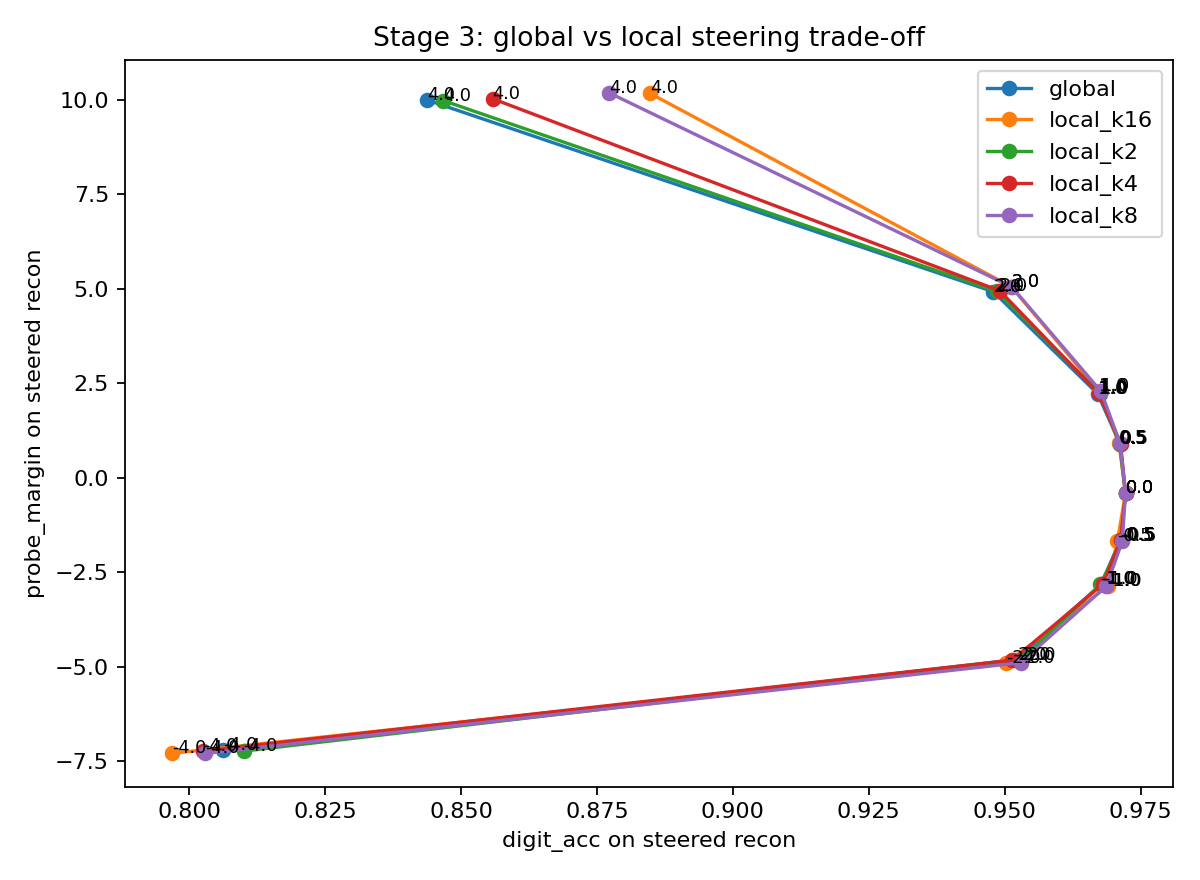

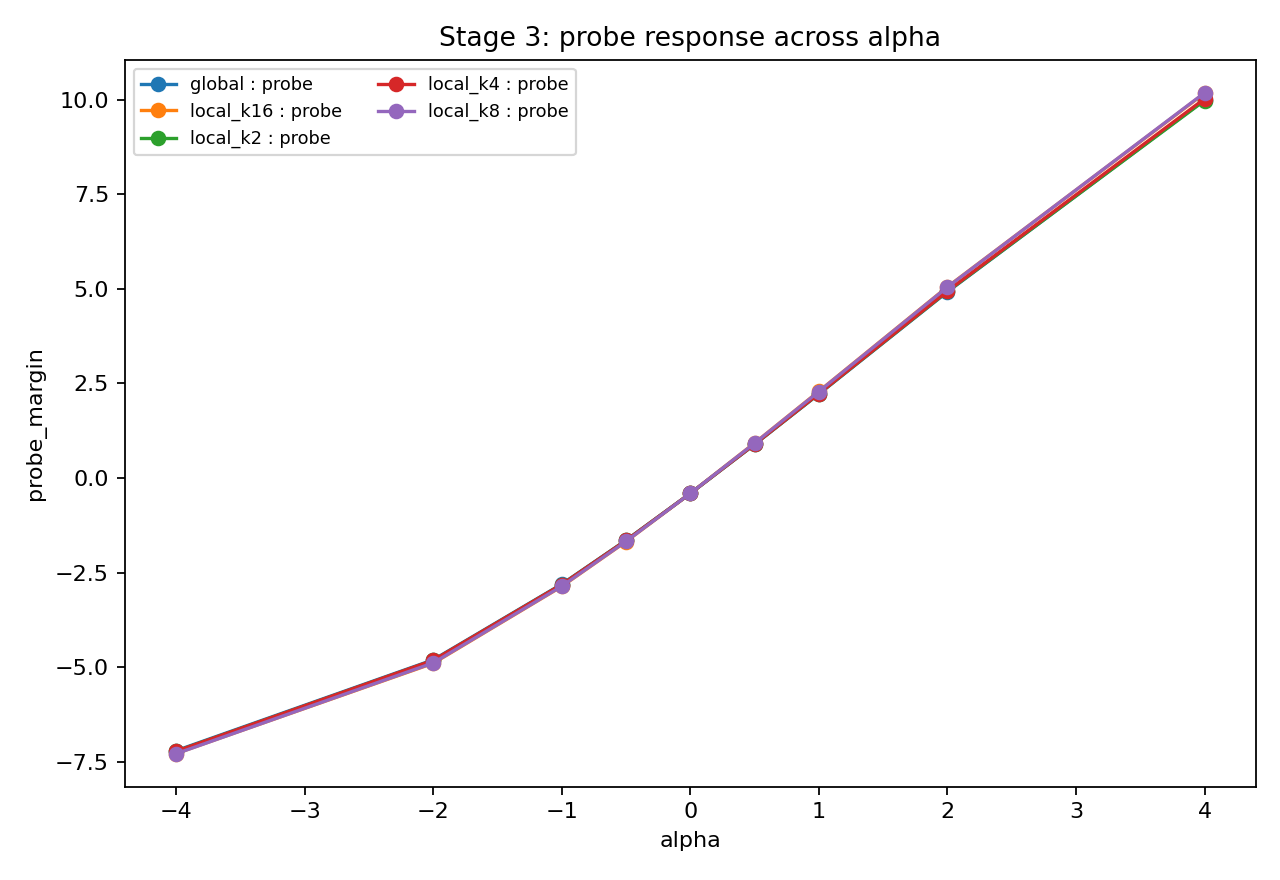

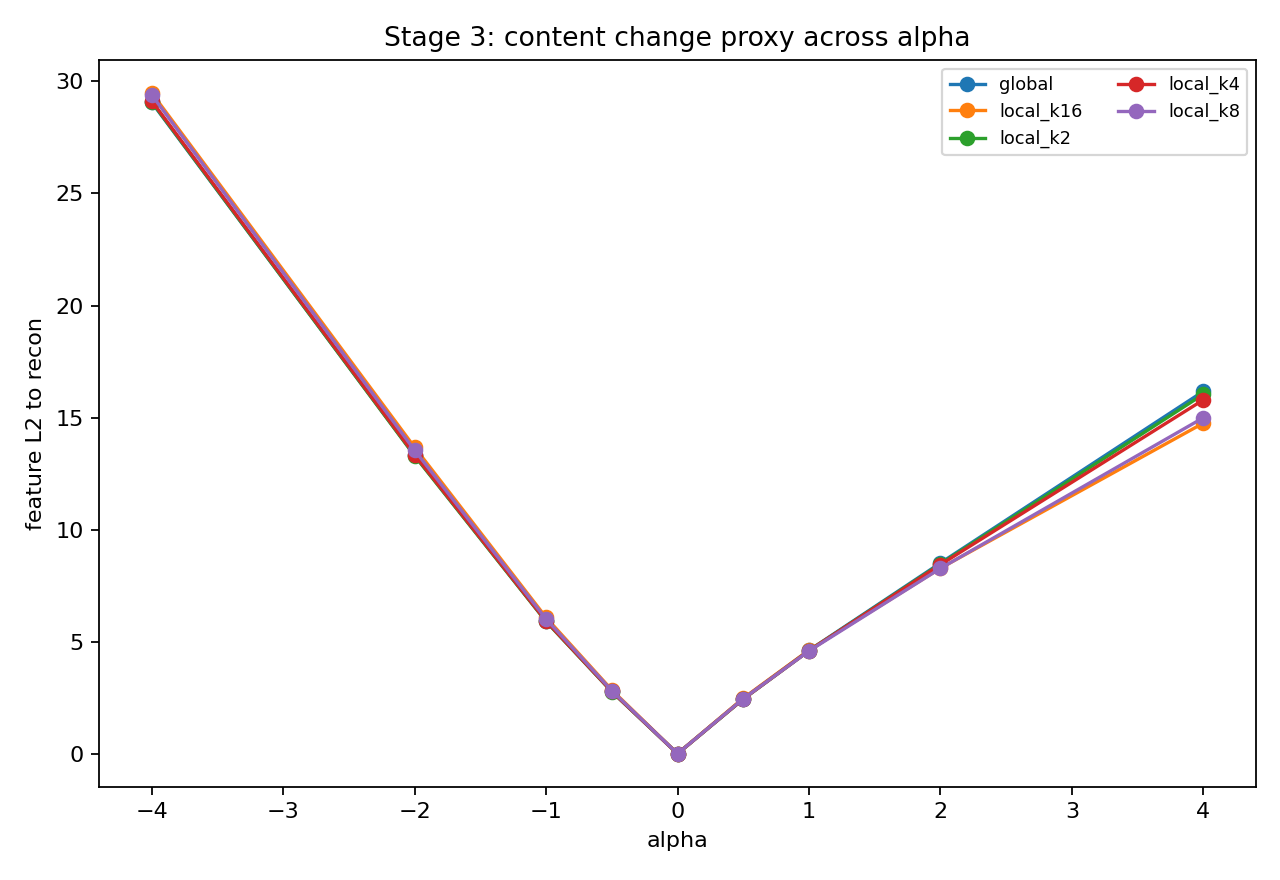

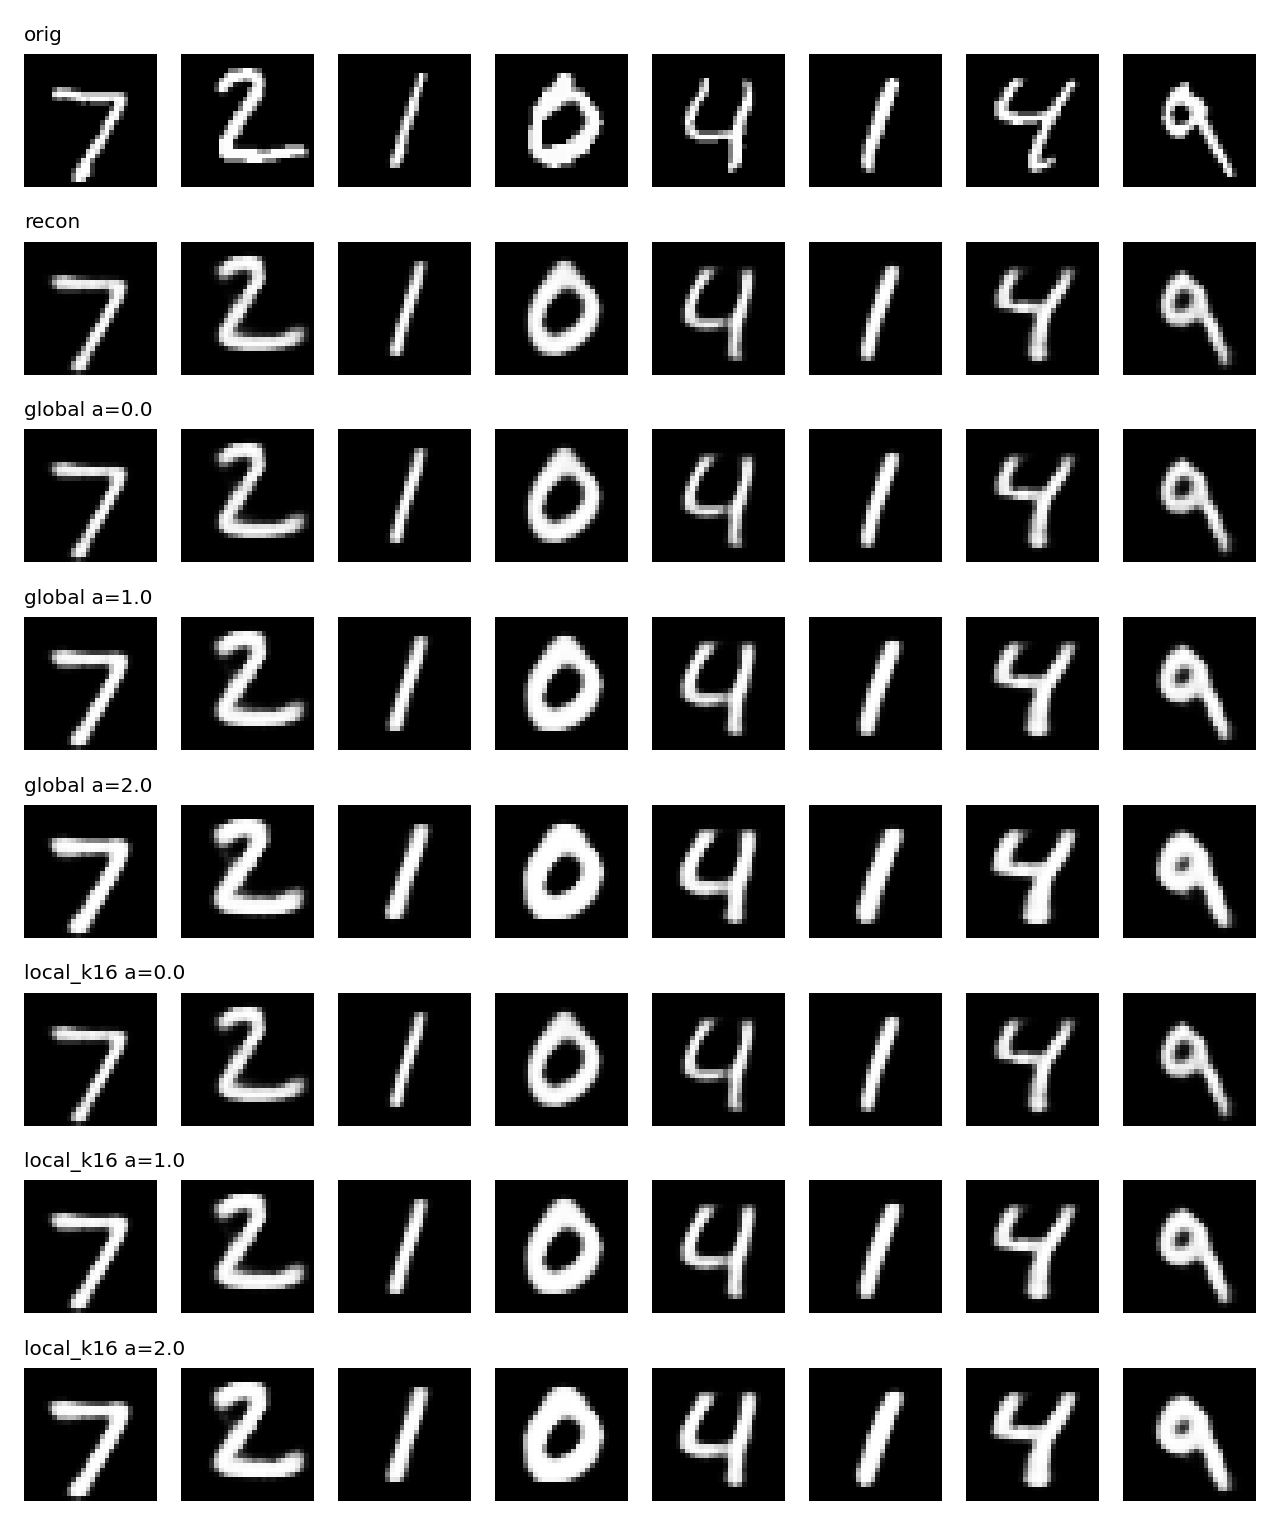

In [12]:

# Optional: show the key plots that were saved to disk
plot_dir = os.path.join(run_dir, "plots")
for name in [
    "tradeoff_global_vs_local.png",
    "probe_vs_alpha_global_vs_local.png",
    "feature_penalty_vs_alpha.png",
    "preview_global_vs_local.png",
]:
    p = os.path.join(plot_dir, name)
    if os.path.exists(p):
        display(Image(filename=p))
